In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from queuing_model.queuing_model import que_mgc, que_mgc_server_wq, queue_wq_roh_coop

In [2]:
lambda_target = 5
waiting_times = [5, 10, 15, 20]


que_mgc_server_wq(lambda_target, 45, 10, waiting_times, 'coop') #(lambda_target, ladezeit, stdabw_lz, wartezeiten, method, max_server=1000):

(5, {'5': 7, '10': 6, '15': 5, '20': 5})

In [3]:
queue_25_adan = que_mgc(25, 10, 5, 32,'adan') #que_mgc(ladezeit, stdabw_lz, mean_wartezeit, max_server, method)

In [4]:
queue_25_adan.to_csv('warteschlange_adan_25_10_5_32.csv') 

In [5]:
queue_25 = que_mgc(25, 10, 5, 32,'coop')

In [14]:
queue_25.to_csv('warteschlange_coop_25_10_5_32.csv')

In [6]:
roh_range = np.arange(0, 0.999, 0.002)
ladezeit = 25
#queue_wq_lambda_coop(lambda_max, server, ladezeit, stdabw_lz)
queue_2_server = queue_wq_roh_coop(roh_range, 2, ladezeit, 10)
queue_4_server = queue_wq_roh_coop(roh_range, 4, ladezeit, 10)
queue_8_server = queue_wq_roh_coop(roh_range, 8, ladezeit, 10)
queue_10_server = queue_wq_roh_coop(roh_range, 10, ladezeit, 10)
queue_15_server = queue_wq_roh_coop(roh_range, 15, ladezeit, 10)
queue_20_server = queue_wq_roh_coop(roh_range, 20, ladezeit, 10)

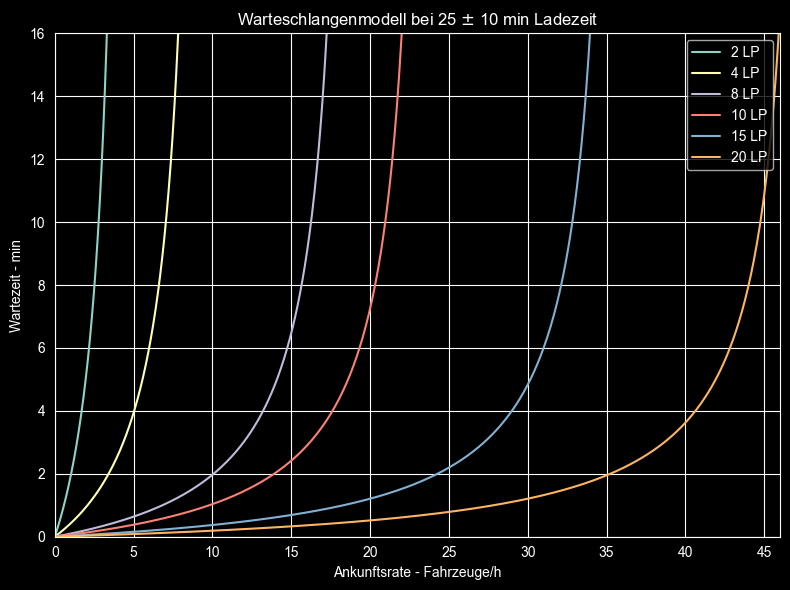

In [7]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='lambda', y='wq_mgc', data=queue_2_server, ax=ax, label='2 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_4_server, ax=ax, label='4 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_8_server, ax=ax, label='8 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_10_server, ax=ax, label='10 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_15_server, ax=ax, label='15 LP')
sns.lineplot(x='lambda', y='wq_mgc', data=queue_20_server, ax=ax, label='20 LP')
plt.ylim(0, 16)
plt.xlim(0, 46)
plt.xticks(np.arange(0, 46, 5))
#plt.yscale('log')
plt.xlabel('Ankunftsrate - Fahrzeuge/h')
plt.ylabel('Wartezeit - min')
plt.title(f'Warteschlangenmodell bei {ladezeit} $\pm$ 10 min Ladezeit')
plt.legend()
plt.tight_layout()
plt.savefig(f'figs/warte_{ladezeit}_ankunft_vs_zeit.jpg')
plt.show()

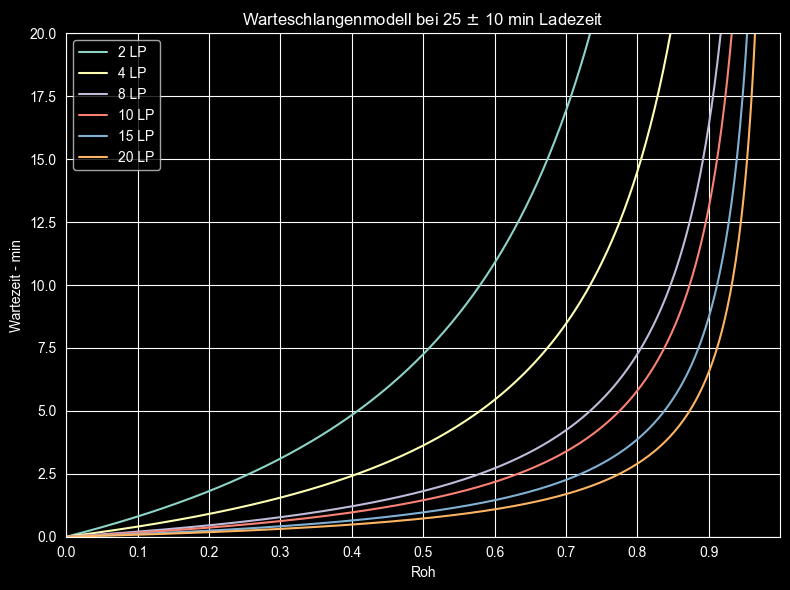

In [8]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='roh', y='wq_mgc', data=queue_2_server, ax=ax, label='2 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_4_server, ax=ax, label='4 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_8_server, ax=ax, label='8 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_10_server, ax=ax, label='10 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_15_server, ax=ax, label='15 LP')
sns.lineplot(x='roh', y='wq_mgc', data=queue_20_server, ax=ax, label='20 LP')
plt.ylim(0, 20)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1, 0.1))
#plt.yscale('log')
plt.xlabel('Roh')
plt.ylabel('Wartezeit - min')
plt.title(f'Warteschlangenmodell bei {ladezeit} $\pm$ 10 min Ladezeit')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
queue_20_server[(queue_20_server['roh'] > 0.75) & (queue_20_server['roh'] < 0.85)]

,lambda,server,roh,wq,wq_mgc,wz/az,krit_wert
36.096,36.096,20.0,0.752,3.790323,2.198387,0.087935,1.8048
36.192,36.192,20.0,0.754,3.831301,2.222154,0.088886,1.8096
36.288,36.288,20.0,0.756,3.872951,2.246311,0.089852,1.8144
36.384,36.384,20.0,0.758,3.915289,2.270868,0.090835,1.8192
36.480,36.480,20.0,0.760,3.958333,2.295833,0.091833,1.8240
36.576,36.576,20.0,0.762,4.002101,2.321218,0.092849,1.8288
36.672,36.672,20.0,0.764,4.046610,2.347034,0.093881,1.8336
36.768,36.768,20.0,0.766,4.091880,2.373291,0.094932,1.8384
36.864,36.864,20.0,0.768,4.137931,2.400000,0.096000,1.8432
36.960,36.960,20.0,0.770,4.184783,2.427174,0.097087,1.8480


In [10]:
ladezeit_que = 25
queue_warte_1 = que_mgc(ladezeit_que, 10, 1, 32,'coop')
queue_warte_2 = que_mgc(ladezeit_que, 10, 2, 32,'coop')
queue_warte_5 = que_mgc(ladezeit_que, 10, 5, 32,'coop')
queue_warte_10 = que_mgc(ladezeit_que, 10, 10, 32,'coop')
queue_warte_15 = que_mgc(ladezeit_que, 10, 15, 32,'coop')

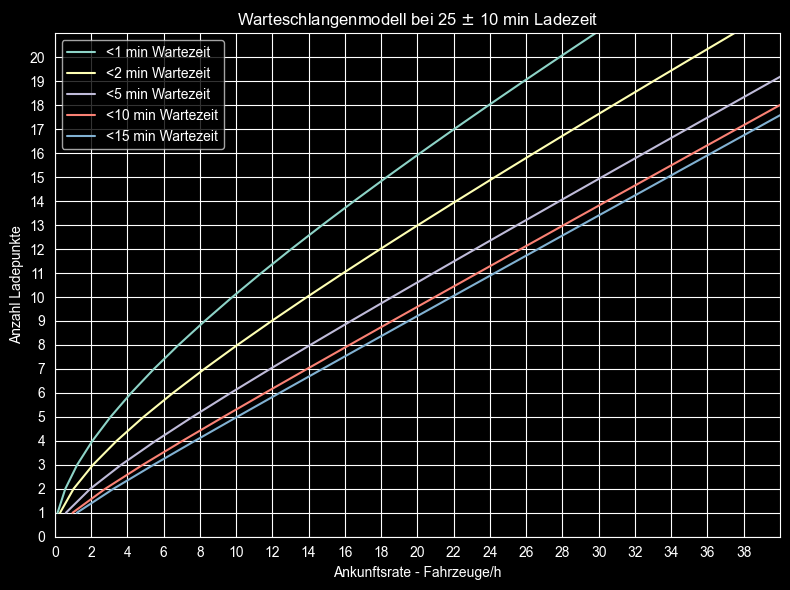

In [11]:
fig, ax = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
sns.lineplot(x='lambda', y='servers', data=queue_warte_1, ax=ax, label='<1 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_2, ax=ax, label='<2 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_5, ax=ax, label='<5 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_10, ax=ax, label='<10 min Wartezeit')
sns.lineplot(x='lambda', y='servers', data=queue_warte_15, ax=ax, label='<15 min Wartezeit')
plt.ylim(0, 21)
plt.xlim(0, 40)
plt.xticks(np.arange(0, 40, 2))
plt.yticks(np.arange(0, 21, 1))
plt.ylabel('Anzahl Ladepunkte')
plt.xlabel('Ankunftsrate - Fahrzeuge/h')
plt.legend()
plt.title(f'Warteschlangenmodell bei {ladezeit_que} $\pm$ 10 min Ladezeit')
plt.tight_layout()
plt.savefig(f'figs/warte_{ladezeit_que}_ankunft_vs_ladepunkte.jpg')
plt.show()

In [12]:
queue_warte_5

,servers,lambda,roh,wq,wq_mgc,wz/az
1,1.0,0.6153,0.256375,8.619096,4.999075,0.199963
2,2.0,1.9591,0.408146,8.620068,4.999639,0.199986
3,3.0,3.6610,0.508472,8.620608,4.999953,0.199998
4,4.0,5.5652,0.579708,8.620626,4.999963,0.199999
5,5.0,7.5949,0.632908,8.620576,4.999934,0.199997
6,6.0,9.7078,0.674153,8.620512,4.999897,0.199996
7,7.0,11.8787,0.707065,8.620472,4.999874,0.199995
8,8.0,14.0917,0.733943,8.620591,4.999942,0.199998
9,9.0,16.3361,0.756301,8.620615,4.999957,0.199998
10,10.0,18.6046,0.775192,8.620584,4.999939,0.199998
